In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("C:/Users/mestr/Downloads/diabetesprac6.csv")

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [56]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size = 0.2, random_state = 0
)

In [58]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)   
X_test = sc.transform(X_test)         

In [26]:
from sklearn.naive_bayes import GaussianNB

In [33]:
model = GaussianNB()

In [34]:
guassian.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [37]:
Y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [44]:
accuracy = accuracy_score(y_test, Y_pred)
precision = precision_score(y_test, Y_pred, average='micro')
recall = recall_score(y_test, Y_pred, average='micro')


In [42]:
accuracy

0.7792207792207793

In [43]:
precision

0.6511627906976745

In [45]:
recall

0.7792207792207793

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, Y_pred)

print(cm)

[[92 15]
 [19 28]]


In [48]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

In [49]:
IQR

Pregnancies                  5.000000
Glucose                     40.500000
BloodPressure               16.000000
SkinThickness               11.463542
Insulin                     47.450521
BMI                          9.100000
DiabetesPedigreeFunction     0.382500
Age                         17.000000
Outcome                      1.000000
dtype: float64

In [50]:
df_no_outlier = df[~((df < (Q1 - 1.5 * IQR)) |
                    (df > (Q3 + 1.5 * IQR))).any(axis=1)]

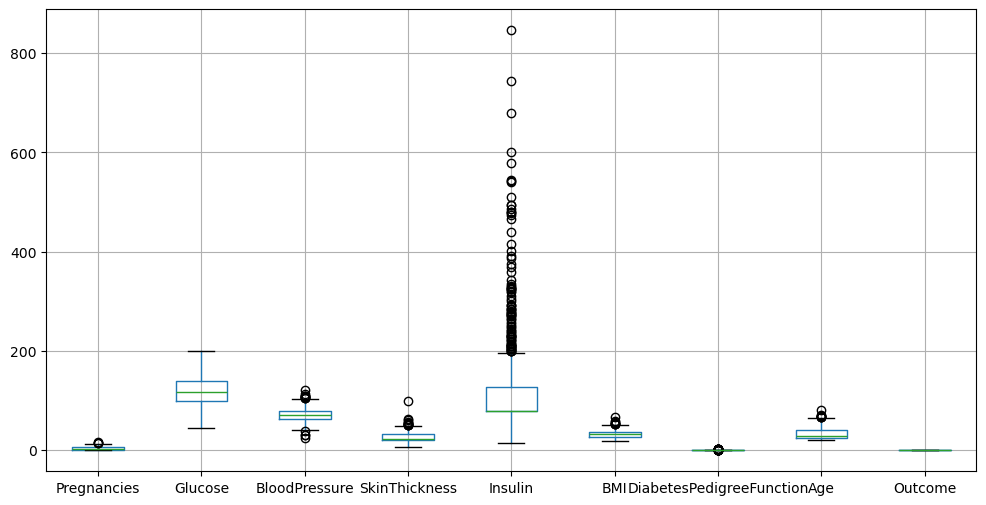

In [52]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(12,6))
plt.show()

In [59]:
for col in df.columns[:-1]:  
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    df[col] = df[col].clip(lower, upper)

In [61]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0          6.0    148.0           72.0      35.000000   79.799479  33.6   
1          1.0     85.0           66.0      29.000000   79.799479  26.6   
2          8.0    183.0           64.0      20.536458   79.799479  23.3   
3          1.0     89.0           66.0      23.000000   94.000000  28.1   
4          0.0    137.0           40.0      35.000000  168.000000  43.1   

   DiabetesPedigreeFunction   Age  Outcome  
0                     0.627  50.0        1  
1                     0.351  31.0        0  
2                     0.672  32.0        1  
3                     0.167  21.0        0  
4                     1.200  33.0        1  


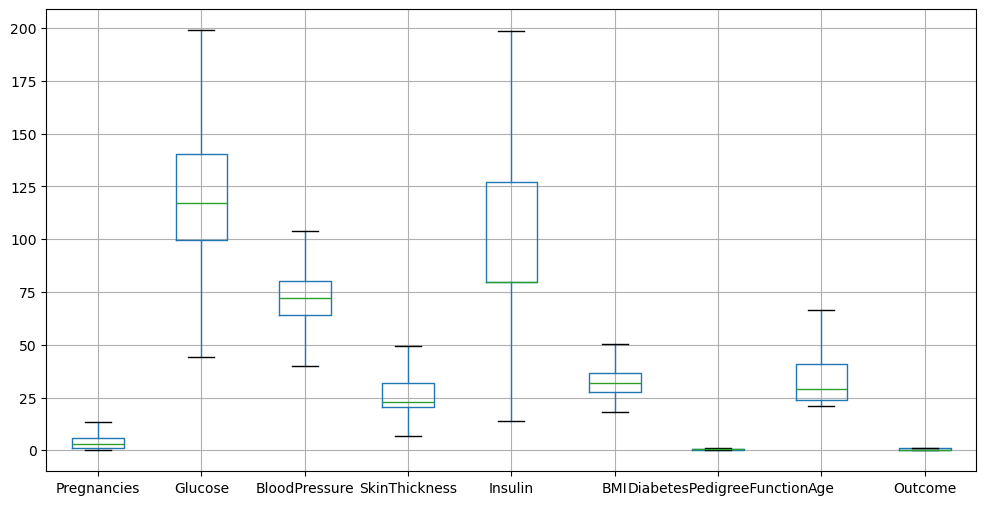

In [62]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(12,6))
plt.show()

<Axes: >

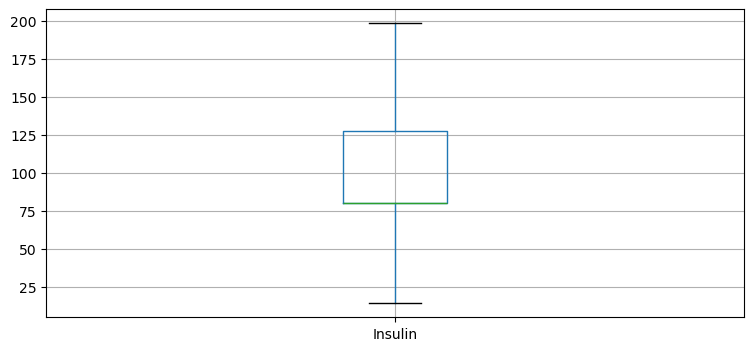

In [63]:
col=['Insulin']
df[col].boxplot(figsize=(9,4))

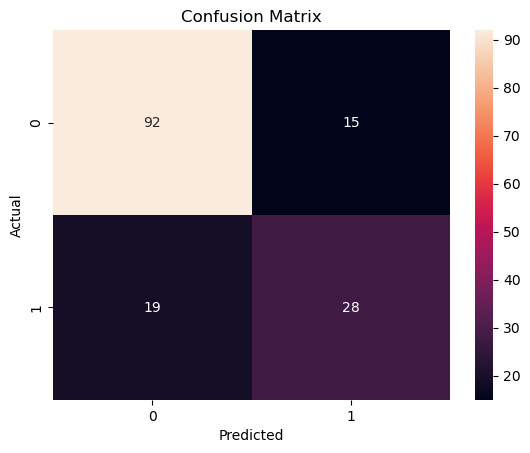

In [64]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()